In [1]:
import sys
import os

# # Add the current file’s directory (or parent) to sys.path
# sys.path.append(os.path.dirname(os.path.abspath(__file__)))
# OR, if you’re in a Jupyter notebook:
# Go up two levels from the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# Add that directory to Python's import path
sys.path.append(parent_dir)

In [2]:
import yaml
import torch
import sys, os

# Go to project root (two parents up from tests/)
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(project_root)

# Import
from src.blocks.SpectrogramBlock import SpectrogramBlock


# Load YAML
with open("../../configs/spectrogram.yaml", "r") as f:
    cfg = yaml.safe_load(f)

device = "mps"


# Build the block
model = SpectrogramBlock(cfg, device)




In [3]:
import torchaudio
import random
from pathlib import Path

# --- Load a random example audio file ---
examples_dir = Path("../../example").resolve()
wav_files = list(examples_dir.glob("*.wav"))
if not wav_files:
    raise FileNotFoundError(f"No .wav files found in {examples_dir}")

random_file = random.choice(wav_files)
print(f"🎵 Using random file: {random_file.name}")

waveform, sr = torchaudio.load(random_file)

🎵 Using random file: pop_example.wav


In [4]:
# Run a test
x = waveform  # Add batch dimension: (1, 1, num_samples)
spec_dict = model(x)

print(spec_dict.keys())  # Should show the keys in the output dictionary

dict_keys(['freq_spec', 'time_spec', 'recon_spec'])


In [5]:
for key, value in spec_dict.items():
    print(f"{key}: {value.shape}")

freq_spec: torch.Size([1, 3, 2001, 201])
time_spec: torch.Size([1, 3, 501, 801])
recon_spec: torch.Size([1, 3, 1001, 401])


In [6]:
import matplotlib.pyplot as plt
import torch

def visualize_spectrogram_parts(spectrogram, title="Spectrogram"):
    """
    Visualizes the real, imaginary, and log-magnitude parts of a spectrogram.
    Works with shape (B, 3, F, T) or (3, F, T).
    Displays each as a separate figure.
    """
    # --- Handle batch dimension ---
    if spectrogram.ndim == 4:  # (B, 3, F, T)
        spectrogram = spectrogram[0]
    elif spectrogram.ndim != 3:
        raise ValueError("Expected spectrogram shape (B, 3, F, T) or (3, F, T).")

    if spectrogram.shape[0] != 3:
        raise ValueError("Spectrogram must have 3 channels: real, imag, log-magnitude.")

    real_part = spectrogram[0].cpu().numpy()
    imag_part = spectrogram[1].cpu().numpy()
    log_mag = spectrogram[2].cpu().numpy()

    # --- Real part ---
    plt.figure(figsize=(10, 4))
    plt.imshow(real_part, origin='lower', aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.title(f"{title} - Real Part")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()

    # --- Imaginary part ---
    plt.figure(figsize=(10, 4))
    plt.imshow(imag_part, origin='lower', aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.title(f"{title} - Imaginary Part")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()

    # --- Log Magnitude ---
    plt.figure(figsize=(10, 4))
    plt.imshow(log_mag, origin='lower', aspect='auto', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{title} - Log Magnitude (dB)")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()


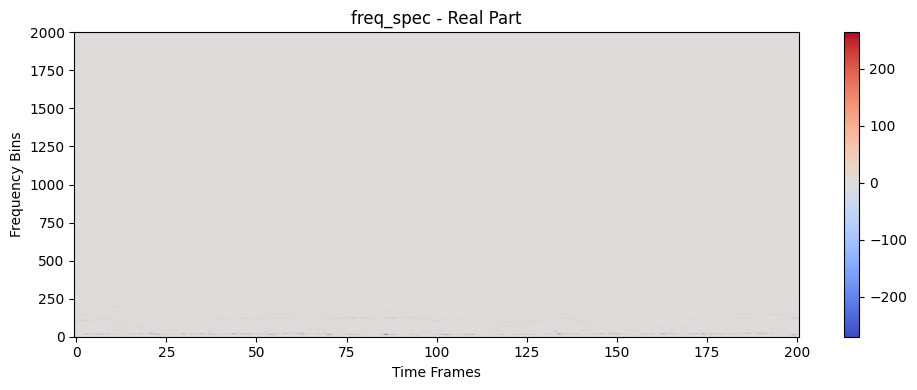

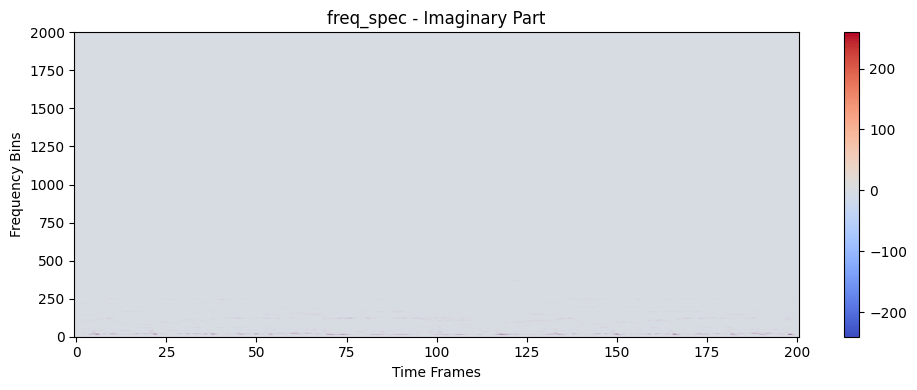

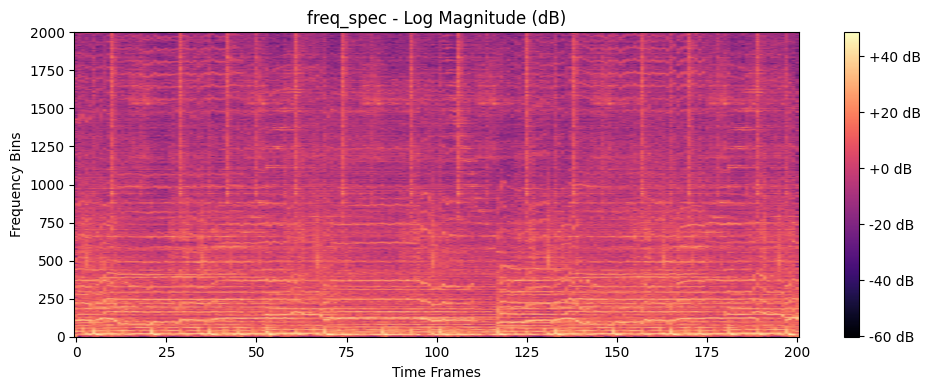

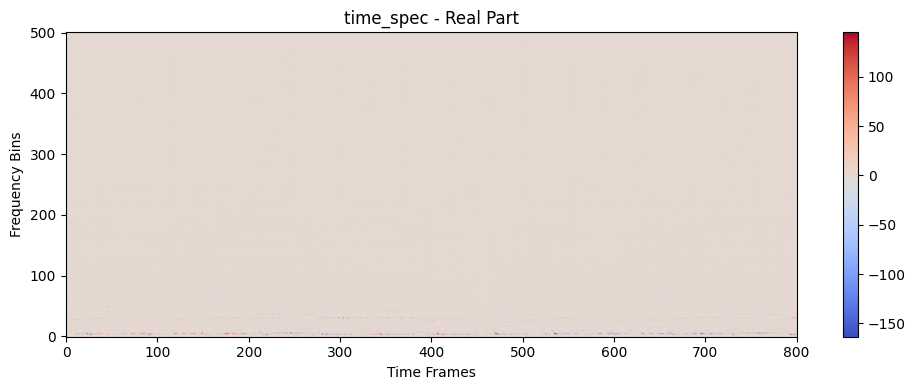

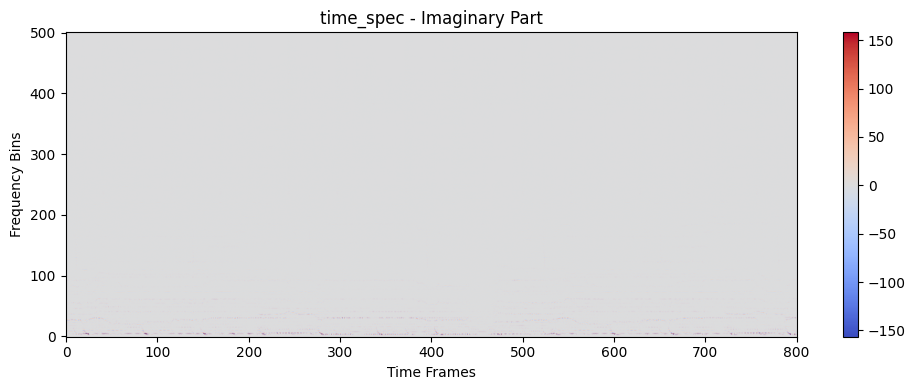

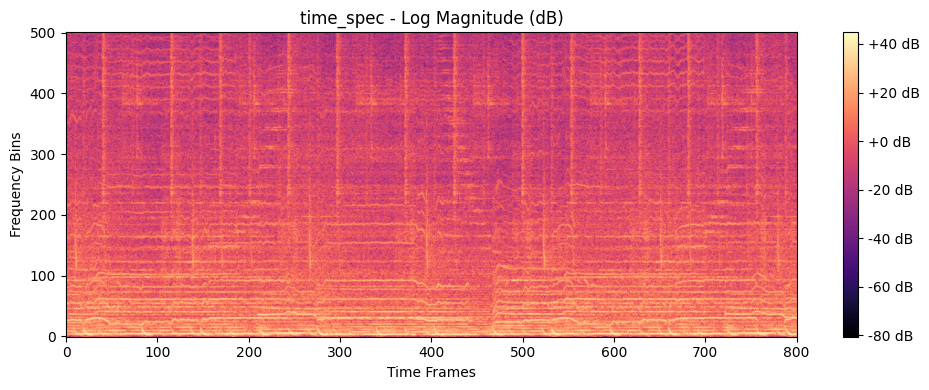

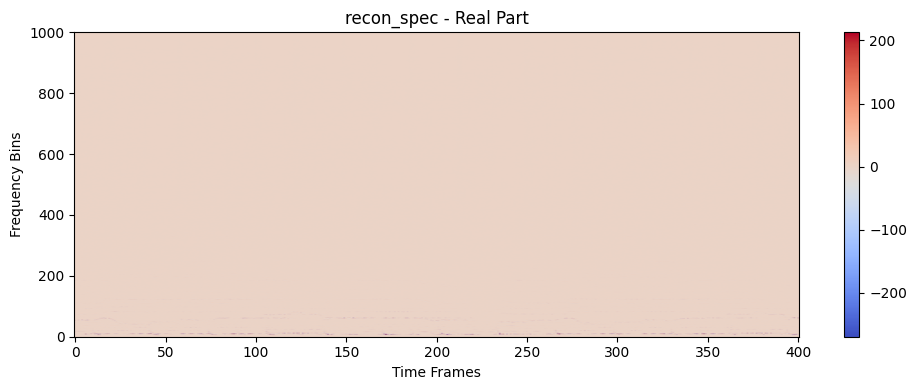

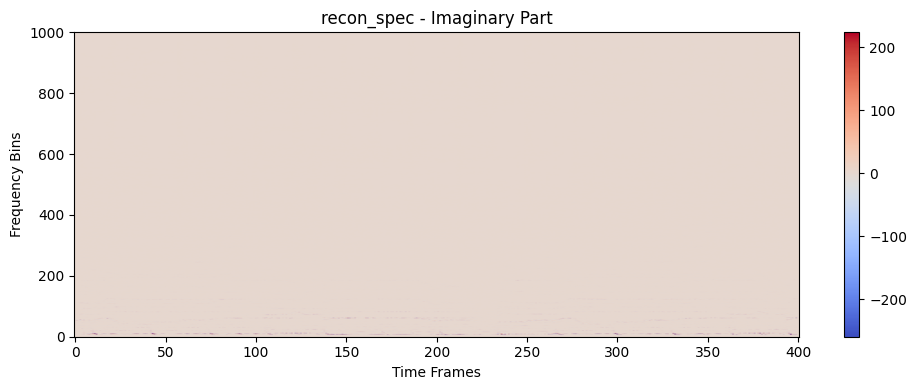

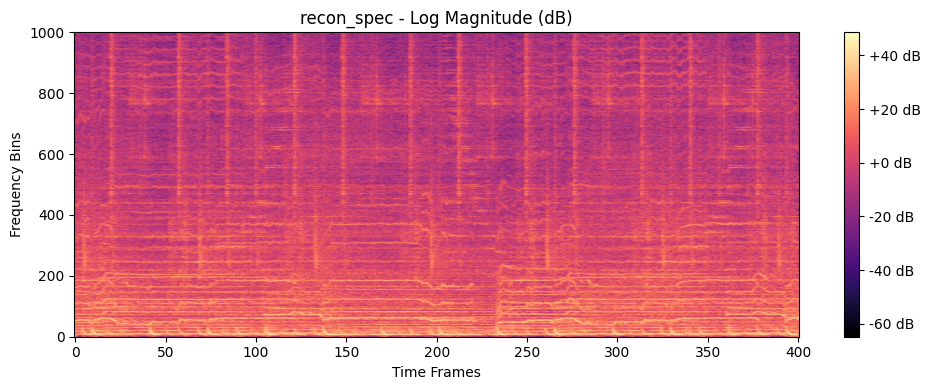

In [7]:

for key, value in spec_dict.items():
    # if key == "recon_wave":  # skip waveform
    #     continue
    visualize_spectrogram_parts(value, title=key)



In [8]:
spec_dict['freq_spec']

tensor([[[[ 1.3687e+01,  4.7712e-02, -4.4405e-01,  ...,  1.0378e+01,
            3.2160e+00,  1.1075e+01],
          [-1.3784e+01, -2.5431e-02,  1.8996e-01,  ..., -1.0070e+01,
           -2.5468e+00, -1.0360e+01],
          [ 1.3957e+01,  3.1325e-03,  3.4017e-01,  ...,  9.5059e+00,
            8.7489e-01,  9.5038e+00],
          ...,
          [-6.1213e-01,  4.2008e-01,  3.7509e-02,  ..., -1.6692e-01,
           -9.7478e-01,  1.8391e-01],
          [ 8.6012e-01, -4.2035e-01,  1.0445e-01,  ...,  1.9239e-01,
            1.1989e+00, -1.8146e-01],
          [-9.7766e-01,  4.1375e-01, -1.6746e-01,  ..., -2.1658e-01,
           -1.2827e+00,  1.7231e-01]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 6.5811e-07,  7.8540e-03, -3.8655e-01,  ..., -1.2068e-01,
            1.9575e+00, -8.4686e-03],
          [-3.7630e-07,  2.5835e-02,  4.1213e-01,  ..., -3.8244e-02,
           -3.4452e+00,  2.4920e-02],
          ...,
     

In [9]:
from src.blocks.InvSpecBlock import InvSpecBlock
# Load YAML
with open("../../configs/invspec.yaml", "r") as f:
    cfg_1 = yaml.safe_load(f)

params1 = cfg_1

invmodel = InvSpecBlock(cfg_1)

In [10]:
recon_spec = spec_dict["recon_spec"]  # shape: (B, 3, F, T)


recon_spec_2ch = recon_spec[:, :2, :, :]  # (B, 2, F, T)


reconstructed_waveform = invmodel(recon_spec_2ch)

print("Reconstructed waveform shape:", reconstructed_waveform.shape)

Reconstructed waveform shape: torch.Size([1, 1, 240000])


In [11]:
from IPython.display import Audio
Audio(reconstructed_waveform[0].cpu().numpy(), rate=sr)

In [12]:
from src.blocks.ConvBlock import ConvBlock

# Load YAML
with open("../../configs/encoder_1.yaml", "r") as f:
    cfg_conv = yaml.safe_load(f)

print(cfg_conv)

{'model': {'name': 'EncoderModel1', 'notes': 'This is Encoder Model 1 configuration file. Design Guidelines: - layer1 blocks are going to be 8 branches in parallel. - squish_freq and squish_time layers should have same dimensions to allow merging. - merge_node block should always have in_channels as number of branches (8) * out_channels of time + freq layers (8*(4+4)=64) - merge_node block should always have out_channels as 32.  - After merge_node the dimensions should be (B, 32, 501, 201) - secondarylayer blocks are 4 parallel branches. - end dimension before final linear layer should have dimension (B, 2, 50, 20)\n', 'blocks': [{'id': 'ConvLayer', 'type': 'layer1', 'params': {'in_channels': 3, 'out_channels': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'activation': 'LeakyReLU', 'batch_norm': True}}, {'id': 'ConvLayer2', 'type': 'layer1', 'params': {'in_channels': 4, 'out_channels': 8, 'kernel_size': 5, 'stride': 1, 'padding': 2, 'activation': 'LeakyReLU', 'batch_norm': True}}, {

In [13]:
conv1 = ConvBlock(cfg_conv['model']['blocks'][0]['params'])

In [14]:
freq_spec = spec_dict['freq_spec']  # (B, 1, F, T)
time_spec = spec_dict['time_spec']  # (B, 1, F, T)

conv_freq = conv1(freq_spec)
print("Conv on freq_spec output shape:", conv_freq.shape)

conv_time = conv1(time_spec)
print("Conv on time_spec output shape:", conv_time.shape)

Conv on freq_spec output shape: torch.Size([1, 4, 2001, 201])
Conv on time_spec output shape: torch.Size([1, 4, 501, 801])


In [15]:
conv2 = ConvBlock(cfg_conv['model']['blocks'][1]['params'])

conv_f = ConvBlock(cfg_conv['model']['blocks'][2]['params'])
conv_t = ConvBlock(cfg_conv['model']['blocks'][3]['params']
                   )

In [16]:
conv_freq = conv2(conv_freq)
print("Conv2 on conv_freq output shape:", conv_freq.shape)
conv_time = conv2(conv_time)
print("Conv2 on conv_time output shape:", conv_time.shape)

conv_freq 
conv_time 

print("After concatenation:")
print("conv_freq shape:", conv_freq.shape)
print("conv_time shape:", conv_time.shape)

conv_freq = conv_f(conv_freq)
print("Conv_f on conv_freq output shape:", conv_freq.shape)
conv_time = conv_t(conv_time)
print("Conv_t on conv_time output shape:", conv_time.shape)

Conv2 on conv_freq output shape: torch.Size([1, 8, 2001, 201])
Conv2 on conv_time output shape: torch.Size([1, 8, 501, 801])
After concatenation:
conv_freq shape: torch.Size([1, 8, 2001, 201])
conv_time shape: torch.Size([1, 8, 501, 801])
Conv_f on conv_freq output shape: torch.Size([1, 4, 501, 201])
Conv_t on conv_time output shape: torch.Size([1, 4, 501, 201])


In [17]:
conv_stacked = torch.cat([conv_freq, conv_time], dim=1)
print("After final concatenation, conv_stacked shape:", conv_stacked.shape)

After final concatenation, conv_stacked shape: torch.Size([1, 8, 501, 201])


In [18]:
conv3 = ConvBlock(cfg_conv['model']['blocks'][5]['params'])

conv4 = ConvBlock(cfg_conv['model']['blocks'][6]['params'])

In [19]:
final = conv3(conv_stacked)
print("After 1st part of final conv layer:", final.shape)

final = conv4(final)
print("After 2nd part of final conv layer:", final.shape)


After 1st part of final conv layer: torch.Size([1, 4, 250, 100])
After 2nd part of final conv layer: torch.Size([1, 2, 50, 20])


In [20]:
with open("../../configs/decoder_1.yaml", "r") as f:
    decoder_cfg = yaml.safe_load(f)

def parse_decoder_cfg(trans):
    blocks = trans['model']['blocks']
    length = len(blocks)
    pair_blocks = []
    for i in range(0, length - 2, 2):
        pair_blocks.append((blocks[i]['params'], blocks[i + 1]['params']))
    final_block = blocks[-1]['params']
    return pair_blocks, final_block

In [21]:
pair, final = parse_decoder_cfg(decoder_cfg)

In [22]:
print("Paired blocks:", pair)

Paired blocks: [({'in_channels': 1, 'out_channels': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'activation': 'ReLU', 'batch_norm': True}, {'in_channels': 16, 'out_channels': 4, 'kernel_size': 7, 'stride': 5, 'padding': 1, 'activation': 'LeakyReLU', 'batch_norm': True}), ({'in_channels': 4, 'out_channels': 8, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'activation': 'ReLU', 'batch_norm': True}, {'in_channels': 32, 'out_channels': 8, 'kernel_size': 6, 'stride': 2, 'padding': 1, 'activation': 'LeakyReLU', 'batch_norm': True})]


In [23]:
for conv_layer, trans_layer in pair:
    print("Conv Layer Params:", conv_layer)
    print(" Trans Layer Params:", trans_layer)

Conv Layer Params: {'in_channels': 1, 'out_channels': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'activation': 'ReLU', 'batch_norm': True}
 Trans Layer Params: {'in_channels': 16, 'out_channels': 4, 'kernel_size': 7, 'stride': 5, 'padding': 1, 'activation': 'LeakyReLU', 'batch_norm': True}
Conv Layer Params: {'in_channels': 4, 'out_channels': 8, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'activation': 'ReLU', 'batch_norm': True}
 Trans Layer Params: {'in_channels': 32, 'out_channels': 8, 'kernel_size': 6, 'stride': 2, 'padding': 1, 'activation': 'LeakyReLU', 'batch_norm': True}


In [24]:
from src.models.combined.encoder_decoder import EncoderDecoderModel
from utils.load_all_configs import load_all_configs
configs = load_all_configs(config="large_model")

device = "mps"

model = EncoderDecoderModel(configs=configs).to(device=device)

In [25]:
model.eval()

EncoderDecoderModel(
  (spectrogram): SpectrogramBlock(
    (to_spec_f): Spectrogram()
    (to_spec_t): Spectrogram()
    (recon_to_spec): Spectrogram()
  )
  (inv_spectrogram): InvSpecBlock(
    (reconspec_to_waveform): InverseSpectrogram()
  )
  (encoder): EncoderModel1(
    (branch_1): ModuleList(
      (0-7): 8 x ConvFirstBranch(
        (conv_blocks): ModuleList(
          (0): ConvBlock(
            (block): Sequential(
              (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU()
            )
          )
          (1): ConvBlock(
            (block): Sequential(
              (0): Conv2d(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
              (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): LeakyReLU(negative_slope=0.01)
            )
         

In [26]:
param_size = 0
for param in model.parameters():
    param_size += param.numel()
print("Total model parameters:", param_size)

Total model parameters: 12422426


In [27]:
waveform = waveform.to(device)
print("Input waveform shape:", waveform.shape)



Input waveform shape: torch.Size([1, 240000])


In [28]:
recon, mu, var, target = model(waveform)

In [29]:
recon.shape, mu.shape, var.shape, target.shape

(torch.Size([1, 2, 1002, 402]),
 torch.Size([1, 1024]),
 torch.Size([1, 1024]),
 torch.Size([1, 3, 1001, 401]))